In [1]:
SIMULATION_EDITION = "motif3"




src_opju = fr"C:\usrspace\mywork\{SIMULATION_EDITION}.opju"

In [2]:
import originpro as op
import numpy as np
import pandas as pd
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import os

# Very useful, especially during development, when you are
# liable to have a few uncaught exceptions.
# Ensures that the Origin instance gets shut down properly.
# Note: only applicable to external Python.
import sys
import draw.pymatlab2.origin_function.write2origin as write2origin
def origin_shutdown_exception_hook(exctype, value, traceback):
    '''Ensures Origin gets shut down if an uncaught exception'''
    op.exit()
    sys.__excepthook__(exctype, value, traceback)
if op and op.oext:
    sys.excepthook = origin_shutdown_exception_hook

import  re
# Set Origin instance visibility.
# Important for only external Python.
# Should not be used with embedded Python.
if op.oext:
    op.set_show(True)


# Example of opening a project and reading data.

# We'll open the Tutorial Data.opju project that ships with Origin.
# src_opju = r"C:\usrspace\mywork\SIMULATION_EDITION.opju"   # <— 用绝对路径；注意路径和文件名是否正确
print("File exists? ", os.path.exists(src_opju))
ok = op.open(file=src_opju)
print("Project opened? ", ok)
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap
from config import DATA_DIR,INPUT_DIR
from pathlib import Path

File exists?  True
Project opened?  True


In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin

测试

In [ ]:

# ===== 2) 列出所有页面类型，看看有没有工作簿 =====
wbooks = list(op.pages('w'))   # 所有工作簿（Worksheet Book）
mbks   = list(op.pages('m'))   # 所有矩阵簿（Matrix Book）
graphs = list(op.pages('g'))   # 所有图页（Graph），仅排查
notes  = list(op.pages('n'))   # 所有Notes，仅排查

print("#Workbooks:", len(wbooks), "| #MatrixBooks:", len(mbks), "| #Graphs:", len(graphs), "| #Notes:", len(notes))

# ===== 3) 如果有工作簿：打印每个工作簿下所有工作表名 =====
for wb in wbooks:
    sheet_names = [wks.name for wks in wb]
    print(f"[{wb.name}] -> {sheet_names}")

# ===== 4) 如果是矩阵簿：打印矩阵表名（有些项目只有矩阵簿，没有工作簿）=====
for mb in mbks:
    ms_names = [ms.name for ms in mb]
    print(f"[{mb.name}] (Matrix) -> {ms_names}")

# ===== 5) 若你想强行拿到第一个工作簿并遍历 =====
if wbooks:
    wb = wbooks[0]
    print("Active to:", wb.name)
    wb.activate()  # 让它成为激活窗口
    for wks in wb:
        print("Sheet:", wks.name)

In [ ]:

# test for a single file
time_2_build = 30
TIME_2_BUILD = time_2_build
from pathlib import Path
# 默认用 "topology_{TIME_2_BUILD}"，也允许用环境变量 TOPOLOGY_VERSION 覆盖
# VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{TIME_2_BUILD}")
DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"
filename = f"pending_edges_ttb{TIME_2_BUILD}"
FIGURE_DIR = Path(FIGURE_DIR)           # 确保是 Path
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book="Book1", sheet=filename, clear=True)

In [ ]:
#when we finished the write to the origin ,we first need fill the gap
# mod_gap.py
from __future__ import annotations
import pandas as pd
from typing import Iterable, Optional, Sequence
import draw.pymatlab2.origin_function.csv2origin as csv2origin

import draw.pymatlab2.origin_function.fillgap as fillgap


fillgap.origin_fill_time_gaps(
    book="Book1",
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)

## 读入p1 p2 数据

这里读入的，就是p1 和p2的数据

In [ ]:
SIMULATION_EDITION

In [ ]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [   30  ]
BOOKname = "Book1"
for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"p1_pending_edges_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)
    filename = f"p2_pending_edges_ttb{ttb}"
    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的
    fillgap.origin_fill_time_gaps(
    book=BOOKname,
    sheet=filename,     # 原表名
    time_start=0,
    step=1,
    fill_value=0,
    dest_sheet=None,    # None=覆盖写回原表；也可以 "xxx_filled"
    clear_dest=True
)


## 合成总建链状态

有了p1和p2接下来是合成两者，两者意味着网络建链随时间的变化

In [ ]:
# -*- coding: utf-8 -*-
# 主要是用这段代码

import pandas as pd
import originpro as op
# 假设 draw.pymatlab2.origin_function 存在且包含 ensure_sheet
from draw.pymatlab2.origin_function import write2origin
Source_BOOK = 'Book1'
TARGET_BOOK = 'Book2'

def _pick_ttb(name: str):
    """从工作表名中抽取末尾的 ttb 数字：...ttb60 -> 60"""
    m = re.search(r'(?<=ttb)\s*(\d+)\s*$', name)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\s*$', name)  # 兜底
    return int(m2.group(1)) if m2 else None

def _load_data_by_prefix(bk, prefix: str) -> dict[int, pd.DataFrame]:
    """遍历以 prefix 开头的工作表，返回 {ttb: DataFrame}，并以 time 为索引。"""
    data_map = {}
    for wks in bk:
        nm = wks.name
        if not nm.startswith(prefix):
            continue

        # 加载数据
        df = wks.to_df(head='L')

        # 检查和准备列
        if not {'time','pending_edges'}.issubset(df.columns):
            continue
        df = df[['time', 'pending_edges']].copy()

        # 尝试转换类型
        df['time'] = pd.to_numeric(df['time'], errors='coerce').fillna(-1).astype(int) # 使用-1表示无效时间
        df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce').fillna(0)

        # 移除无效时间点
        df = df[df['time'] >= 0]

        ttb = _pick_ttb(nm)
        if ttb is None:
            continue

        # 以 time 为索引，用于后续的对齐和相加
        data_map[ttb] = df.set_index('time')
    return data_map

def _merge_p1_p2_data(p1_map: dict[int, pd.DataFrame], p2_map: dict[int, pd.DataFrame]) -> dict[int, pd.DataFrame]:
    """
    合并 P1 和 P2 的数据（相同时间点求和），返回 {ttb: Merged DataFrame}。
    """
    all_ttbs = set(p1_map.keys()) | set(p2_map.keys())
    merged_data_map = {}

    for ttb in all_ttbs:
        df1 = p1_map.get(ttb)
        df2 = p2_map.get(ttb)

        # 确保至少有一个数据存在
        if df1 is None and df2 is None:
            continue

        if df1 is None:
            # 只有 P2，直接使用 P2 数据
            merged_series = df2['pending_edges']
        elif df2 is None:
            # 只有 P1，直接使用 P1 数据
            merged_series = df1['pending_edges']
        else:
            # P1 和 P2 都存在，按 time 索引对齐并相加
            # 使用 add(fill_value=0) 实现 outer join 和相加
            merged_series = df1['pending_edges'].add(df2['pending_edges'], fill_value=0)

        # 将 Series 转换回 DataFrame，重置索引，并命名列
        merged_df = merged_series.reset_index(name='merged_pending_edges')
        merged_df = merged_df.rename(columns={'time': 'time'}) # 确保 time 列名正确

        # 最终输出列为: time, merged_pending_edges
        merged_data_map[ttb] = merged_df

    return merged_data_map

# ===== 主流程 =====


bk = op.find_book('w', Source_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{Source_BOOK}'")

# 1. 加载所有 P1 和 P2 的数据
print(f"开始加载数据...")
p1_data_map = _load_data_by_prefix(bk, 'p1_pending_edges_')
p2_data_map = _load_data_by_prefix(bk, 'p2_pending_edges_')
print(f"P1 TTB 数量: {len(p1_data_map)}, P2 TTB 数量: {len(p2_data_map)}")

# 2. 合并 P1 和 P2 的数据
merged_data_map = _merge_p1_p2_data(p1_data_map, p2_data_map)
print(f"完成合并，共有 {len(merged_data_map)} 个 ttb 结果需要写入。")

# 3. 遍历合并结果，并写入新的工作表
print("\n开始写入 Origin 工作表:")
output_ttbs = sorted(merged_data_map.keys())
written_sheets = []

for ttb in output_ttbs:
    df_out = merged_data_map[ttb]
    OUT_SHEET_NAME = f'pending_edges_ttb{ttb}'

    # 确保工作表存在并清空内容
    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET_NAME, clear_existing=True, activate=True)

    # 写入 DataFrame
    # 确保写入的列顺序是 time 和 merged_pending_edges
    ws.from_df(df_out[['time', 'merged_pending_edges']])

    # 设置列信息
    # ws.cols[0].set_labels('X', 'Time')
    # ws.cols[1].set_labels('Y', 'P1 + P2 Pending Edges')

    written_sheets.append(OUT_SHEET_NAME)
    print(f"  -> [{TARGET_BOOK}] {OUT_SHEET_NAME}")

if written_sheets:
    print(f"\n全部写入完成。已创建/更新 {len(written_sheets)} 张工作表：")
    print(", ".join(written_sheets))
else:
    print("没有找到匹配的 P1/P2 数据进行合并，未创建新的工作表。")

###  平均无建链时间时长

No-Setup Link Time Duration(NSLTD) 平均无建链时间持续

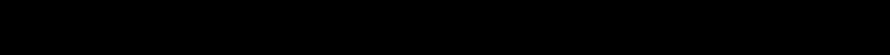
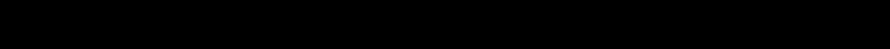
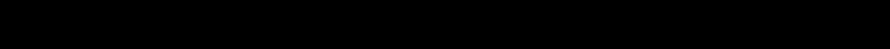

In [ ]:


TARGET_BOOK = 'Book2'
OUT_SHEET   = 'average_time_stable'  # 结果写到这个表（修正拼写）
MIN_WINDOW_LEN_SEC = 1               # 过滤过短片段（单位：秒）
IGNORE_FIRST_SEG = True              # 是否忽略首段

def estimate_step_seconds(t_arr: np.ndarray) -> int:
    """估计时间步长（多数情况下为 1 秒）。"""
    if t_arr.size < 2:
        return 1
    diffs = np.diff(t_arr)
    pos = diffs[diffs > 0]
    if pos.size == 0:
        return 1
    # 众数
    mode_val = int(pd.Series(pos).mode().iat[0])
    return max(1, mode_val)

def calculate(df: pd.DataFrame) -> tuple[float, int, int, int]:
    """
    计算平均/最大/最小“无建链稳定时长”（秒）以及片段数。
    片段定义：pending_edges==0 的极大连续区间（按 time 序列的值连续性，不按行数）。
    """
    # 预处理：只取需要的两列，转数值、去空、按 time 排序
    s = df[['time', 'merged_pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['merged_pending_edges'], errors='coerce').fillna(0)
    s = s.dropna(subset=['time'])
    if s.empty:
        return 0.0, 0, 0, 0

    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    t_arr = s['time'].to_numpy()
    e_arr = s['pending_edges'].astype(int).to_numpy()

    step = estimate_step_seconds(t_arr)

    # 遍历，抽取 pending_edges==0 的极大连续段（按 time 连续性）
    segments: list[tuple[int, int]] = []
    in_zero = (e_arr[0] == 0)
    seg_start = t_arr[0] if in_zero else None
    last_t = t_arr[0]

    for t, e in zip(t_arr[1:], e_arr[1:]):
        # 只要状态没变，就继续；状态变化时收段/开段
        if e == 0 and not in_zero:
            # False -> True：开始新段
            in_zero = True
            seg_start = t
        elif e != 0 and in_zero:
            # True -> False：收尾一段
            in_zero = False
            seg_end = last_t
            segments.append((seg_start, seg_end))
            seg_start = None
        last_t = t

    # 末尾收尾
    if in_zero and seg_start is not None:
        segments.append((seg_start, last_t))

    # 可选：忽略首段
    if IGNORE_FIRST_SEG and len(segments) >= 1:
        segments = segments[1:]

    if not segments:
        return 0.0, 0, 0, 0

    # 计算各段长度（秒）
    lengths = [max(0, (end - start) + step) for (start, end) in segments]
    # 过滤过短片段
    lengths = [L for L in lengths if L >= MIN_WINDOW_LEN_SEC]

    if not lengths:
        return 0.0, 0, 0, 0

    K = len(lengths)
    avg_len = sum(lengths) / K
    max_len = max(lengths)
    min_len = min(lengths)
    return float(avg_len), int(max_len), int(min_len), int(K)

# ============ 主流程 ============
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # 读取（Long Name 为表头）
    df = wks.to_df(head='L')
    if not {'time','merged_pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    avg_len, max_len, min_len, seg_cnt = calculate(df)

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'NSLTD': avg_len,
        'max_stable_time_sec': max_len,
        'min_stable_time_sec': min_len,
        'segments': seg_cnt,
    })

# 汇总并写回 Origin
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'NSLTD', 'max_stable_time_sec',
            'min_stable_time_sec', 'segments']

    print("\n=== SUMMARY (Average Zero-Stable Length, seconds) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


###  平均无建链时间占比
No-Setup Link Time Ratio（NSLTR):平均无建链时间占比

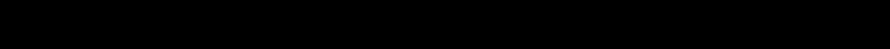

In [ ]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book2'      # 只在 Book1 里统计
OUT_SHEET = 'zero_stable time and Proportion'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_ttb'):
        continue

    # ===== 读取（Long Name 作为表头）=====
    df = wks.to_df(head='L')
    if not {'time','merged_pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [Book1] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','merged_pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['merged_pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [Book1] {nm}")
        continue

    # ===== 未建链占比：edge==0 计为“未建链”；NaN 按 0 处理；不考虑缺口 =====
    observed_seconds = int(len(df))                             # 分母：观测到的总时长（行数）
    no_link_seconds  = int(df['pending_edges'].fillna(0).eq(0).sum())  # 分子：edge==0 的时长
    no_link_ratio    = (no_link_seconds / observed_seconds) if observed_seconds > 0 else 0.0
    no_link_ratio_pct = round(no_link_ratio * 100.0, 4)

    print(f"[Book1] {nm} | no-link={no_link_seconds}s / {observed_seconds}s = {no_link_ratio_pct:.2f}%")

    results.append({
        'book': 'Book1',
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,
        'no_link_seconds': no_link_seconds,
        'no_link_ratio': round(no_link_ratio, 6),
        'NSLTR': no_link_ratio_pct,
    })

# ===== 汇总并写回 Origin(写到 Book1 -> "stable time and Proportion") =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'NSLTR', 'no_link_seconds', 'observed_seconds']

    print("\n=== SUMMARY (No-Link Ratio) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK,  OUT_SHEET,
                                   clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print("写入完成 -> [Book1] stable time and Proportion")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


### 平均建链条数




**meth1:总条数，目前不采用了**

In [ ]:


TARGET_BOOK = 'Book1'
OUT_SHEET   = 'avg_switches'   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）
    max_link = int(pe.max()) if len(pe) else 0
    med_link = float(pe.median()) if len(pe) else 0.0

    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）
        'max_link': max_link,
        'median_link': round(med_link, 4),
    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s):
        try:
            return int(''.join(ch for ch in s if ch.isdigit()))
        except Exception:
            return None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds', 'max_link', 'median_link']

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

mthod2：分析p1 和p2 的

这里的算法，指的是关于处理p1 p2 pending edge的对比

In [ ]:
# 该代码是不用的
TARGET_BOOK = 'Book2'
OUT_SHEET   = 'avg_switches_P1'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('p1_pending_edges_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','pending_edges'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','pending_edges']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['pending_edges'] = pd.to_numeric(df['pending_edges'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    observed_seconds = int(len(df))                        # T
    pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    sum_link = float(pe.sum())                             # Σ L_i
    avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
          f"(sum={sum_link:.0f}, T={observed_seconds}  )")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'time_min': int(df['time'].min()),
        'time_max': int(df['time'].max()),
        'observed_seconds': observed_seconds,   # T
        'sum_link': round(sum_link, 4),         # Σ L_i
        'avg_link': round(avg_link, 6),         # 平均切换条数（每秒）

    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'avg_link', 'sum_link', 'observed_seconds',  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

这个就是描述p1 和p2的一个数据

也就是Average Number of Setup Links(ANSL)



In [ ]:
 # -*- coding: utf-8 -*-
 # 主要是用这段代码
import re
import pandas as pd
import originpro as op
from draw.pymatlab2.origin_function import write2origin

TARGET_BOOK = 'Book1'
OUT_SHEET   = 'avg_switches_P1_P2'   # 一张表里放 p1/p2 的平均值

def _pick_ttb(name: str):
    """从工作表名中抽取末尾的 ttb 数字：...ttb60 -> 60"""
    m = re.search(r'(?<=ttb)\s*(\d+)\s*$', name)
    if m:
        return int(m.group(1))
    m2 = re.search(r'(\d+)\s*$', name)  # 兜底
    return int(m2.group(1)) if m2 else None

def _avg_switches_from_df(df: pd.DataFrame) -> float:
    """计算每秒平均 pending_edges（ΣL_i / T）。"""
    s = df[['time', 'pending_edges']].copy()
    s['time'] = pd.to_numeric(s['time'], errors='coerce')
    s['pending_edges'] = pd.to_numeric(s['pending_edges'], errors='coerce')
    s = s.dropna(subset=['time'])
    if s.empty:
        return float('nan')
    s['time'] = s['time'].astype(int)
    s = s.sort_values('time')
    T = int(len(s))
    if T == 0:
        return float('nan')
    pe = s['pending_edges'].fillna(0)
    return float(pe.sum()) / T

def _collect_avg_by_prefix(bk, prefix: str) -> dict[int, float]:
    """遍历以 prefix 开头的工作表，返回 {ttb: avg}。"""
    out = {}
    for wks in bk:
        nm = wks.name
        if not nm.startswith(prefix):
            continue
        df = wks.to_df(head='L')
        if not {'time','pending_edges'}.issubset(df.columns):
            continue
        ttb = _pick_ttb(nm)
        if ttb is None:
            continue
        out[ttb] = _avg_switches_from_df(df)
    return out

# ===== 主流程 =====
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

p1_map = _collect_avg_by_prefix(bk, 'p1_pending_edges_')
p2_map = _collect_avg_by_prefix(bk, 'p2_pending_edges_')

# 合并到一张表（按 ttb 排序）
ttbs = sorted(set(p1_map) | set(p2_map))
rows = []
for t in ttbs:
    rows.append({
        'ttb': t,
        'avg_link_p1': float(p1_map.get(t, float('nan'))),
        'avg_link_p2': float(p2_map.get(t, float('nan'))),
    })
df_out = pd.DataFrame(rows).sort_values('ttb')

# 写回 Origin
ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
ws.from_df(df_out[['ttb', 'avg_link_p1', 'avg_link_p2']])

print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
print(df_out.to_string(index=False))


## 稳定拓扑

下面介绍的是稳定拓扑，也就是实际上卫星网络工作时候的拓扑形状


In [ ]:
TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
BOOKname = "Book3"
for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
    # VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"topology_snapshot_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)
    #下面是补全，目前的pending edge一般是要补全的




下面都是一些测试

In [ ]:
# 不考虑缺口：仅按观测到的连续行里 pending_edges==0 计算窗口
# 仅遍历 Book1

import draw.pymatlab2.origin_function.write2origin as write2origin

MIN_WINDOW_LEN = 1    # 连续0窗口的最小长度（行数/秒数）
results = []


TARGET_BOOK = 'Book2'      # 只在 Book1 里统计
OUT_SHEET = 'topology_change_summary2'   # 去掉尾部空格，避免重名问题

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"未找到工作簿 '{TARGET_BOOK}'，请确认数据就在此书中。")

sheetname  = "topology_change_summary"
wks = op.find_sheet('w', '[TARGET_BOOK]sheetname')


In [ ]:
 #测试
TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb60'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====


In [ ]:
#测试
import  draw.pymatlab2.origin_function.get_qujian as get_qujian




# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

# print(f"共找到 {len(qujian)} 个稳定区间")
# for i, q in enumerate(qujian, 1):
#     print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
avg_len = np.mean([q.length for q in qujian])
print(f"平均稳定拓扑时长: {avg_len:.2f}")



In [ ]:
 #测试

TARGET_BOOK = 'Book3'
SRC_SHEET   = 'topology_snapshot_ttb10'    # 源表：含 t / link_count / changed


# ===== 1) 用你要求的方式找到源表 =====
wks = op.find_sheet('w', f'[{TARGET_BOOK}]{SRC_SHEET}')
if wks is None:
    raise RuntimeError(f"在工作簿 '{TARGET_BOOK}' 中未找到工作表 '{SRC_SHEET}'")

# ===== 2) 读取数据（用 Long Name 作列名）=====
df = wks.to_df(head='L')
need = {'t','link_count','changed'}
if not need.issubset(df.columns):
    raise RuntimeError(f"源表缺列，需包含 {need}，实际为：{set(df.columns)}")

# 规范化
df['t']          = pd.to_numeric(df['t'], errors='coerce')
df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
df['changed']    = pd.to_numeric(df['changed'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['t','link_count']).sort_values('t').reset_index(drop=True)

# ===== 3) 计算三列：stable_line / change_line / change_mark =====

# df 为包含 t / link_count / changed 的 DataFrame
qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")


for i in range(len(qujian)-1 ):
    if qujian[i].edges ==qujian[i+1].edges :
        print(i)


print(f"共找到 {len(qujian)} 个稳定区间")

for i, q in enumerate(qujian, 1):
    print(f"区间{i}: t∈{q.interval}, 平均边数={q.edges:.1f}, 时长={q.length:.1f}")

# 求平均稳定时长
# avg_len = np.mean([q.length for q in qujian])
# print(f"平均稳定拓扑时长: {avg_len:.2f}")



In [ ]:
# 该代码是不用的
import  draw.pymatlab2.origin_function.get_qujian as get_qujian

TARGET_BOOK = 'Book3'
OUT_SHEET   = 'avg_topology'   # 结果写到这个表
import  re
bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []

for wks in bk:
    nm = wks.name
    if not nm.startswith('topology_snapshot_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'t','link_count','changed'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['t','link_count','changed']].copy()

    df['t'] = pd.to_numeric(df['t'], errors='coerce')
    df['link_count'] = pd.to_numeric(df['link_count'], errors='coerce')
    df['changed'] = pd.to_numeric(df['changed'], errors='coerce')

    df = df.dropna(subset=['t']).copy()
    df['t'] = df['t'].astype(int)
    df = df.sort_values('t')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 平均切换条数（每秒平均）=====
    qujian = get_qujian.extract_stable_intervals(df, rep_stat="mean")

    avg_time_len = np.mean([q.length for q in qujian])
    avg_edges = np.mean([q.edges for q in qujian])
    # observed_seconds = int(len(df))                        # T
    # pe = df['pending_edges'].fillna(0)                     # L_i（NaN 记为 0）
    # sum_link = float(pe.sum())                             # Σ L_i
    # avg_link = sum_link / observed_seconds if observed_seconds > 0 else 0.0  # ΣL_i / T

    # 参考指标（可选）


    # print(f"[{TARGET_BOOK}] {nm} | avg_link={avg_link:.6f}  "
    #       f"(sum={sum_link:.0f}, T={observed_seconds}, max={max_link}, median={med_link:.2f})")

    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'interval_number': len(qujian),
        'MSTD': avg_time_len,   # T
        'MSTE': avg_edges,   # T


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    def _pick_ttb(s: str):
        m = re.search(r'(?<=ttb)\s*(\d+)\s*$', s)  # 优先匹配 "...ttbXX" 末尾
        if m:
            return int(m.group(1))
        m2 = re.search(r'(\d+)\s*$', s)            # 兜底：取末尾数字
        return int(m2.group(1)) if m2 else None



    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    cols = ['ttb', 'interval_number','MSTD',   'MSTE'  ]

    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

## 最短路径的输入

最短路径是不需要进行后期处理的，导入即可

In [ ]:



BOOKname = "Book4"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]
# TTB_VALUES = [  60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)
    # VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"avgspath_{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)



RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"avgspath_0"
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


In [ ]:
BOOKname = "Book4"
FIGURE_DIR    = Path(INPUT_DIR) / "grid+" / "figure"
filename = f"avgspath_g0_4_baseline"
csv1_path = FIGURE_DIR / f"{filename}.csv"

csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


首先探寻lst对平均最短路径的影响

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import re
TARGET_BOOK = 'Book4'
OUT_SHEET   = 'avgspath_all '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('avgspath_'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','avg_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','avg_shortest_path']].copy()
    # df['time'] = pd.to_numeric(df['time'], errors='coerce')
    # df['avg_shortest_path'] = pd.to_numeric(df['avg_shortest_path'], errors='coerce')
    # df = df.dropna(subset=['time']).copy()
    # df['time'] = df['time'].astype(int)
    # df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
# 3. 调用

    df_tv = df[['time', 'avg_shortest_path']].copy()

    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'avg_hops': mean_hops,
            'std_val': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    # def _pick_ttb(s):
    #     try:
    #         return int(''.join(ch for ch in s if ch.isdigit()))
    #     except Exception:
    #         return None
    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'avgspath_[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'avg_hops', 'std_val']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

然后，我们求解，不同lst下，这个lst带来的影响

In [ ]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
import re
TARGET_BOOK = 'Book4'
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book4]avgspath_0')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
base = wks.to_df(head='L')
# print(df.head())
base_tv = base[['time', 'avg_shortest_path']].copy()

OUT_SHEET   = 'avgspath_vs_lst '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('avgspath_'):
        continue
    if nm.startswith('avgspath_0'):
        continue
    if nm.startswith('avgspath_all'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','avg_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','avg_shortest_path']].copy()
    # df['time'] = pd.to_numeric(df['time'], errors='coerce')
    # df['avg_shortest_path'] = pd.to_numeric(df['avg_shortest_path'], errors='coerce')
    # df = df.dropna(subset=['time']).copy()
    # df['time'] = df['time'].astype(int)
    # df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
# 3. 调用

    df_tv = df[['time', 'avg_shortest_path']].copy()

    # 假设 base_tv 也是一个 DataFrame/Series，index 对齐
    diff = df_tv['avg_shortest_path'] - base_tv['avg_shortest_path']

    df_tv_all = pd.DataFrame({
        'time': df_tv['time'],
        'avg_shortest_path_diff': diff,
    })

    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv_all)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'avg_hops': mean_hops,
            'std_val': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)

    # 从 sheet 名里提取 ttb 数字用于排序（可选）
    # def _pick_ttb(s):
    #     try:
    #         return int(''.join(ch for ch in s if ch.isdigit()))
    #     except Exception:
    #         return None
    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'avgspath_[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'avg_hops', 'std_val']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")

In [10]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book8]minhops_huasha_wulumuqi_grid')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df = wks.to_df(head='L')
print(df.head())

df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)


   time  min_shortest_path  best_s  best_d
0   0.0                5.0   539.0   645.0
1   1.0                5.0   539.0   645.0
2   2.0                5.0   539.0   645.0
3   3.0                5.0   539.0   645.0
4   4.0                5.0   539.0   645.0
平均值 = 8.268166325835038
标准差 = 8.772256733999573


感兴趣卫星对的导入

In [ ]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book4]minhops_boling_beijin_ttb60')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df = wks.to_df(head='L')
print(df.head())

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

BOOK5

城市对数据导如

In [11]:


BOOKname = "Book5"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_boling_beijin_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_boling_beijin_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

WSheet: [Book5]minhops_boling_beijin_ttb0

In [ ]:
import  draw.pymatlab2.basic.get_mean_var as get_mean_var

接下来就是求解均指和方差

In [ ]:
# 3. 调用
import  draw.pymatlab2.basic.get_mean_var as get_mean_var
df_tv = df[['time', 'min_shortest_path']].copy()

mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)
print("平均值 =", mean_hops)
print("标准差 =", std_hops)

In [12]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book5'
OUT_SHEET   = 'boling_beijin '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_boling_beijin_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


=== SUMMARY (Average Switch Count) ===
 ttb  mean_hops  std_hops
   0  10.758964  0.530284
  10  10.757964  0.529571
  20  10.759146  0.530366
  30  10.761145  0.534511
  40  10.762918  0.537544
  50  10.762100  0.545494
  60  10.760373  0.546819
  70  10.761191  0.547260
  80  10.760009  0.545661
  90  10.758646  0.543807
 100  10.757373  0.543074
 110  10.760918  0.546892
 120  10.760145  0.545596
 130  10.760145  0.543928
 140  10.758828  0.542885
写入完成 -> [Book5] boling_beijin 


In [13]:


BOOKname = "Book6"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_paris_chongqin_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_paris_chongqin_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

WSheet: [Book6]minhops_paris_chongqin_ttb0

In [14]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book6'
OUT_SHEET   = 'paris_chongqin '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_paris_chongqin_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


=== SUMMARY (Average Switch Count) ===
 ttb  mean_hops  std_hops
   0  11.765099  1.681875
  10  11.764008  1.684800
  20  11.762645  1.684204
  30  11.760509  1.684482
  40  11.756419  1.685918
  50  11.752329  1.687343
  60  11.747057  1.688392
  70  11.744058  1.687698
  80  11.741786  1.688833
  90  11.741786  1.693669
 100  11.744967  1.700604
 110  11.764781  1.700921
 120  11.769461  1.705870
 130  11.768325  1.718286
 140  11.774188  1.723435
写入完成 -> [Book6] paris_chongqin 


In [5]:


BOOKname = "Book7"


TTB_VALUES = [  10,20,30,40,50,60, 70, 80,90, 100, 110, 120,130,140]

for ttb in TTB_VALUES:
    #VERSION = os.getenv("TOPOLOGY_VERSION", f"topology_{ttb}")
    DEFAULT_VERSION = f"{SIMULATION_EDITION}/topology_{ttb}"
    VERSION = os.getenv("TOPOLOGY_VERSION", DEFAULT_VERSION)

    FIGURE_DIR    = Path(INPUT_DIR) / VERSION / "figure"

    filename = f"minhops_huasha_wulumuqi_ttb{ttb}"


    csv1_path = FIGURE_DIR / f"{filename}.csv"

    csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)


RAW_VERSION = f"{SIMULATION_EDITION}/raw"
FIGURE_DIR    = Path(INPUT_DIR) / RAW_VERSION / "figure"
filename = f"minhops_huasha_wulumuqi_ttb0"
csv1_path = FIGURE_DIR / f"{filename}.csv"


csv2origin.csv_to_origin(csv1_path, book=BOOKname, sheet=filename, clear=True)

WSheet: [Book7]minhops_huasha_wulumuqi_ttb0

In [6]:
import draw.pymatlab2.origin_function.write2origin as write2origin
import re
TARGET_BOOK = 'Book7'
OUT_SHEET   = 'huasha_wulumuqi '   # 结果写到这个表

bk = op.find_book('w', TARGET_BOOK)
if bk is None:
    raise RuntimeError(f"找不到工作簿 '{TARGET_BOOK}'")

results = []


for wks in bk:
    nm = wks.name
    if not nm.startswith('minhops_huasha_wulumuqi_ttb'):
        continue

    # ===== 读取（Long Name 为表头）=====
    df = wks.to_df(head='L')
    if not {'time','min_shortest_path'}.issubset(df.columns):
        print(f"跳过（缺列）: [{TARGET_BOOK}] {nm}")
        continue

    # ===== 规范化 =====
    df = df[['time','min_shortest_path']].copy()
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['min_shortest_path'] = pd.to_numeric(df['min_shortest_path'], errors='coerce')
    df = df.dropna(subset=['time']).copy()
    df['time'] = df['time'].astype(int)
    df = df.sort_values('time')

    if df.empty:
        print(f"跳过（空表）: [{TARGET_BOOK}] {nm}")
        continue
    df_tv = df[['time', 'min_shortest_path']].copy()
    mean_hops, std_hops = get_mean_var.calc_mean_std(df_tv)


    results.append({
        'book': TARGET_BOOK,
        'sheet': nm,
        'mean_hops': mean_hops,
            'std_hops': std_hops,                     # ← 新增


    })

# ===== 汇总并写回 Origin =====
if results:
    df_sum = pd.DataFrame(results)


    def _pick_ttb(s: str):
    # 只取 ttb 后面连续的数字，忽略前面的 g0_4 等
        m = re.search(r'ttb[_\s-]*?(\d+)\b', s, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None
    df_sum['ttb'] = df_sum['sheet'].map(_pick_ttb)
    df_sum = df_sum.sort_values(['book','ttb'], na_position='last')

    # cols = ['ttb', 'avg_hops',  ]
    cols = ['ttb', 'mean_hops', 'std_hops']


    print("\n=== SUMMARY (Average Switch Count) ===")
    print(df_sum[cols].to_string(index=False))

    ws = write2origin.ensure_sheet(TARGET_BOOK, OUT_SHEET, clear_existing=True, activate=True)
    ws.from_df(df_sum[cols])

    print(f"写入完成 -> [{TARGET_BOOK}] {OUT_SHEET}")
else:
    print("没有匹配到 pending_edges_* 的工作表。")


=== SUMMARY (Average Switch Count) ===
 ttb  mean_hops  std_hops
   0   5.707885  5.611321
  10   5.744558  5.665521
  20   5.779914  5.717971
  30   5.815042  5.770080
  40   5.850170  5.822017
  50   5.877800  5.873447
  60   5.901659  5.917574
  70   5.935742  5.958665
  80   5.972779  5.996828
  90   6.012088  6.030933
 100   6.059532  6.054065
 110   6.125335  6.067923
 120   6.174688  6.087708
 130   6.220541  6.110867
 140   6.272802  6.135940
写入完成 -> [Book7] huasha_wulumuqi 


In [15]:
# 找到 [Book5]test 这个工作表

wks = op.find_sheet('w', '[Book6]minhops_paris_chongqin_ttb60')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df1 = wks.to_df(head='L')
print(df.head())

   time  min_shortest_path
0     0               12.0
1     1               12.0
2     2               12.0
3     3               12.0
4     4               12.0


In [16]:

wks = op.find_sheet('w', '[Book6]minhops_paris_chongqin_ttb0')
if wks is None:
    raise RuntimeError("找不到工作表 [Book5]test")

# 读成 DataFrame，首行作为列名
df2 = wks.to_df(head='L')
print(df.head())

   time  min_shortest_path
0     0               12.0
1     1               12.0
2     2               12.0
3     3               12.0
4     4               12.0


In [19]:
df2


,time,min_shortest_path,best_s,best_d
0,0,12.0,325,121
1,1,12.0,325,121
2,2,12.0,325,121
3,3,12.0,325,121
4,4,12.0,325,121
...,...,...,...,...
22000,22000,9.0,104,427
22001,22001,9.0,104,427
22002,22002,9.0,104,427
22003,22003,9.0,104,427


In [20]:
for i in range(22005):
    if df1.loc[i, 'min_shortest_path'] < df2.loc[i, 'min_shortest_path']:
        print(i)


20574
20575
20576
20577
20578
20579
20580
20581
20582
20583
20584
20585
20586
20587
20588
20589
20590
20591
20592
20593
20594
20595
20596
20597
20598
20599
20600
20601
20602
20603
20604
20605
20606
20607
20608
20609
20610
20628
20629
20630
20631
20632
20633
20634
20635
20636
20637
20638
20639
20640
20641
20642
20643
20644
20645
20646
20647
20648
20649
20650
20651
20652
20653
20654
20655
20656
20657
20658
20659
20660
20661
20662
20663
20664
20665
20666
20667
20668
20669
20670
20671
20672
20673
20674
20675
20676
20677
20678
20679
20680
20681
20682
20683
20684
20685
20686
20687
20688
20689
20690
20691
20692
20693
20694
20695
20696
20697
20698
20699
20700
20701
20702
20703
20704
20705
20706
20707
20708
20709
20710
20711
20712
20713
20714
20715
20716
20717
20718
20719
20720
20721
20722
20723
20724
20725
20726
20727
20728
20729
20730
20731
20732
20733
20734
20735
20736
20737
20738
20739
20740
20741
20742
20743
20744
20745
20746
20747
20748
20749
20750
20751
20752
20753
20754
20755
20756
2075